In [18]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from wordcloud import WordCloud

In [20]:
df = pd.read_csv('balanced_ai_human_prompts.csv')
df

,text,generated
0,"Machine learning, a subset of artificial intel...",1
1,"A decision tree, a prominent machine learning ...",1
2,"Education, a cornerstone of societal progress,...",1
3,"Computers, the backbone of modern technology, ...",1
4,"Chess, a timeless game of strategy and intelle...",1
...,...,...
2745,Generate a detailed summary of global healthca...,1
2746,Compose an in-depth exploration of financial t...,1
2747,Generate a detailed summary of autonomous vehi...,1
2748,Develop a persuasive argument about internet o...,1


In [22]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2750 entries, 0 to 2749
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       2750 non-null   object
 1   generated  2750 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 43.1+ KB


In [24]:
df.columns

Index(['text', 'generated'], dtype='object')

In [25]:
df['generated'].value_counts()

generated
1    1375
0    1375
Name: count, dtype: int64

In [26]:
STOPWORDS = {
    'the','is','in','and','to','of','a','for','on','with','as','this','that',
    'it','are','was','were','be','by','an','or','from','at','not','but'
}

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)        # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)     # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [w for w in words if w not in STOPWORDS]
    
    return " ".join(words)


In [27]:
df['clean_text'] = df['text'].apply(preprocess_text)

df[['text', 'clean_text', 'generated']].head()


,text,clean_text,generated
0,"Machine learning, a subset of artificial intel...",machine learning subset artificial intelligenc...,1
1,"A decision tree, a prominent machine learning ...",decision tree prominent machine learning algor...,1
2,"Education, a cornerstone of societal progress,...",education cornerstone societal progress extend...,1
3,"Computers, the backbone of modern technology, ...",computers backbone modern technology have revo...,1
4,"Chess, a timeless game of strategy and intelle...",chess timeless game strategy intellect transce...,1


In [28]:
human_text = " ".join(df[df['generated'] == 0]['clean_text'])
ai_text = " ".join(df[df['generated'] == 1]['clean_text'])


In [29]:
human_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    prefer_horizontal=0.9
).generate(human_text)

ai_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    prefer_horizontal=0.2,
    max_font_size=120
).generate(ai_text)

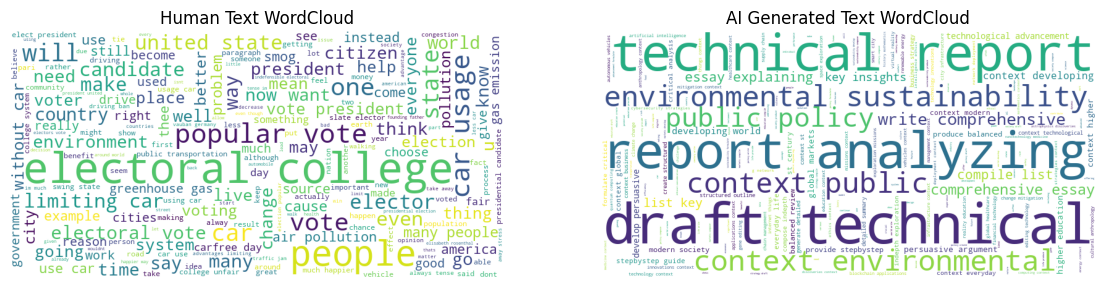

In [30]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(human_wc)
plt.title("Human Text WordCloud")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ai_wc)
plt.title("AI Generated Text WordCloud")
plt.axis("off")

plt.show()